# Fine-Tuning de Modelos en Azure AI Foundry

Este notebook presenta un flujo profesional para **fine-tuning de GPT-4o-mini** en **Azure AI Foundry**, orientado a un caso real de **Gourmet Service & Dish Prediction**.

El objetivo es especializar el modelo para:  
1. Recomendar los mejores platos según **clima** e **inventario**.  
2. Estimar **tiempos de servicio** y **dotación de personal** de forma consistente.

Se cubre la preparación de datos, ejecución del fine-tuning, monitoreo, análisis de métricas, pruebas comparativas y estrategia de mejora continua en producción.

## 0) Setup y Entorno

Antes de ejecutar el pipeline, prepara un archivo **.env** en la raíz del proyecto con las credenciales de Azure OpenAI:

- AZURE_OPENAI_ENDPOINT
- AZURE_OPENAI_API_KEY
- AZURE_OPENAI_API_VERSION
- AZURE_OPENAI_BASE_DEPLOYMENT (despliegue base)
- AZURE_OPENAI_FT_DEPLOYMENT (despliegue fine-tuned, cuando exista)
- PORTAL_FINE_TUNE_JOB_ID (Job ID del entrenamiento ejecutado en Portal)

También se recomienda trabajar con entorno virtual para garantizar reproducibilidad:

1. Crear entorno virtual.
2. Activarlo.
3. Instalar dependencias: openai (v1+), python-dotenv, pandas, matplotlib y azure-storage-blob.

Este enfoque reduce errores de versiones y facilita la colaboración en equipo.

In [103]:
# Optional: install dependencies in notebook context
# %pip install --upgrade openai python-dotenv pandas matplotlib

import os
import json
import time
import random
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from openai import AzureOpenAI, BadRequestError

load_dotenv()

AZURE_OPENAI_ENDPOINT = os.getenv("AZURE_OPENAI_ENDPOINT")
AZURE_OPENAI_API_KEY = os.getenv("AZURE_OPENAI_API_KEY")
AZURE_OPENAI_API_VERSION = os.getenv("AZURE_OPENAI_API_VERSION", "2024-05-01-preview")
AZURE_OPENAI_BASE_DEPLOYMENT = os.getenv("AZURE_OPENAI_BASE_DEPLOYMENT", "gpt-4o-mini")
AZURE_OPENAI_FT_DEPLOYMENT = os.getenv("AZURE_OPENAI_FT_DEPLOYMENT", "gpt-4o-mini-2024-07-18-gourmet-v1")
BASE_MODEL_NAME = os.getenv("BASE_MODEL_NAME", "gpt-4o-mini-2024-07-18")
PORTAL_FINE_TUNE_JOB_ID = os.getenv("PORTAL_FINE_TUNE_JOB_ID", "")

required_vars = {
    "AZURE_OPENAI_ENDPOINT": AZURE_OPENAI_ENDPOINT,
    "AZURE_OPENAI_API_KEY": AZURE_OPENAI_API_KEY,
}

missing = [k for k, v in required_vars.items() if not v]
if missing:
    raise EnvironmentError(f"Missing required environment variables: {missing}")

client = AzureOpenAI(
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    api_key=AZURE_OPENAI_API_KEY,
    api_version=AZURE_OPENAI_API_VERSION,
)

print("AzureOpenAI client initialized successfully.")
print(f"Configured fine-tuning base model: {BASE_MODEL_NAME}")
print(f"Configured base deployment: {AZURE_OPENAI_BASE_DEPLOYMENT}")
print(f"Configured fine-tuned deployment: {AZURE_OPENAI_FT_DEPLOYMENT}")
if PORTAL_FINE_TUNE_JOB_ID:
    print(f"Portal job id detected from .env: {PORTAL_FINE_TUNE_JOB_ID}")

AzureOpenAI client initialized successfully.
Configured fine-tuning base model: gpt-4o-mini
Configured base deployment: gpt-4o-mini
Configured fine-tuned deployment: gpt-4o-mini-2024-07-18-gourmet-v1
Portal job id detected from .env: ftjob-89ce5e0b798e482f802b48399c34a82b


## 1) Preparación del Dataset (JSONL)

Para fine-tuning supervisado en formato Chat Completions, cada registro debe contener una conversación estructurada con roles `system`, `user` y `assistant`.

En este caso generamos **100 ejemplos sintéticos** y aplicamos partición **80/20**:

- **80% entrenamiento**: aprende patrones de recomendación y staffing.
- **20% validación**: mide capacidad de generalización en datos no vistos.

Esta división ayuda a detectar sobreajuste y evaluar si el modelo mantiene calidad fuera de entrenamiento.

In [104]:
RANDOM_SEED = 42
TOTAL_EXAMPLES = 100
TRAIN_RATIO = 0.8

random.seed(RANDOM_SEED)

dishes_by_temperature = [
    ((28, 40), ["Gazpacho", "Ceviche", "Salmorejo", "Tartar de Atun"]),
    ((18, 27), ["Risotto de Setas", "Salmón a la Plancha", "Ensalada Gourmet", "Pasta al Pesto"]),
    ((5, 17), ["Crema de Calabaza", "Estofado de Ternera", "Ramen de Autor", "Lasaña de Verduras"]),
]

inventory_levels = ["high", "medium", "low"]
service_types = ["lunch", "dinner", "event"]

def suggest_dish(temp_c, meat_stock, fish_stock, veg_stock):
    for (low, high), options in dishes_by_temperature:
        if low <= temp_c <= high:
            candidate_pool = options.copy()
            break
    else:
        candidate_pool = ["Chef Special"]

    if meat_stock == "low":
        candidate_pool = [d for d in candidate_pool if "Ternera" not in d]
    if fish_stock == "low":
        candidate_pool = [d for d in candidate_pool if "Atun" not in d and "Salmón" not in d and "Ceviche" not in d]
    if veg_stock == "low":
        candidate_pool = [d for d in candidate_pool if "Ensalada" not in d and "Verduras" not in d]

    if not candidate_pool:
        if temp_c >= 28:
            return "Gazpacho"
        if temp_c >= 18:
            return "Risotto de Setas"
        return "Crema de Calabaza"

    return random.choice(candidate_pool)

def estimate_staff_and_time(people_count, service_type):
    waiter_capacity = 8 if service_type == "event" else 10
    kitchen_capacity = 18 if service_type == "lunch" else 15

    waiters = max(1, (people_count + waiter_capacity - 1) // waiter_capacity)
    cooks = max(1, (people_count + kitchen_capacity - 1) // kitchen_capacity)

    base_time = 14 if service_type == "lunch" else 18
    service_time_min = base_time + int(people_count * 0.8)
    return waiters, cooks, service_time_min

def build_example():
    temp_c = random.randint(5, 40)
    people_count = random.randint(2, 40)
    service_type = random.choice(service_types)
    meat_stock = random.choice(inventory_levels)
    fish_stock = random.choice(inventory_levels)
    veg_stock = random.choice(inventory_levels)

    dish = suggest_dish(temp_c, meat_stock, fish_stock, veg_stock)
    waiters, cooks, service_time_min = estimate_staff_and_time(people_count, service_type)

    user_prompt = (
        f"Weather: {temp_c}C. Guests: {people_count}. Service: {service_type}. "
        f"Inventory -> meat: {meat_stock}, fish: {fish_stock}, vegetables: {veg_stock}. "
        "Recommend best dish and staffing plan."
    )

    assistant_answer = (
        f"Recommended dish: {dish}. "
        f"Estimated staffing: {waiters} waiters and {cooks} cooks. "
        f"Estimated service time: {service_time_min} minutes."
    )

    return {
        "messages": [
            {
                "role": "system",
                "content": "You are a gourmet operations assistant specialized in dish recommendation and service planning."
            },
            {
                "role": "user",
                "content": user_prompt
            },
            {
                "role": "assistant",
                "content": assistant_answer
            }
        ]
    }

all_examples = [build_example() for _ in range(TOTAL_EXAMPLES)]
split_index = int(TOTAL_EXAMPLES * TRAIN_RATIO)
train_examples = all_examples[:split_index]
val_examples = all_examples[split_index:]

assert len(train_examples) == 80, "Training split must be 80 examples."
assert len(val_examples) == 20, "Validation split must be 20 examples."

def write_jsonl(path, rows):
    with open(path, "w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

write_jsonl("training_set.jsonl", train_examples)
write_jsonl("validation_set.jsonl", val_examples)

print("Dataset created successfully:")
print(f" - training_set.jsonl: {len(train_examples)} examples")
print(f" - validation_set.jsonl: {len(val_examples)} examples")

Dataset created successfully:
 - training_set.jsonl: 80 examples
 - validation_set.jsonl: 20 examples


In [105]:
# Quick quality check with pandas
def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

train_rows = read_jsonl("training_set.jsonl")
val_rows = read_jsonl("validation_set.jsonl")

sample_records = []
for row in train_rows[:5]:
    user_msg = row["messages"][1]["content"]
    assistant_msg = row["messages"][2]["content"]
    sample_records.append({
        "user": user_msg,
        "assistant": assistant_msg
    })

df_preview = pd.DataFrame(sample_records)
display(df_preview.head())
print(f"Train size: {len(train_rows)} | Validation size: {len(val_rows)}")

,user,assistant
0,Weather: 12C. Guests: 3. Service: event. Inven...,Recommended dish: Estofado de Ternera. Estimat...
1,Weather: 11C. Guests: 36. Service: lunch. Inve...,Recommended dish: Crema de Calabaza. Estimated...
2,Weather: 10C. Guests: 15. Service: lunch. Inve...,Recommended dish: Lasaña de Verduras. Estimate...
3,Weather: 17C. Guests: 36. Service: dinner. Inv...,Recommended dish: Estofado de Ternera. Estimat...
4,Weather: 5C. Guests: 12. Service: event. Inven...,Recommended dish: Estofado de Ternera. Estimat...


Train size: 80 | Validation size: 20


## 2) Fine-Tuning Process (Modalidad Elegida: Portal + SDK de Soporte)

Para esta práctica se eligió oficialmente la **Modalidad Portal (Azure AI Foundry Studio)**, ya que el trabajo de entrenamiento se ejecutó y completó correctamente desde la interfaz.

Como complemento técnico, este notebook mantiene celdas en Python SDK para automatización, validación y monitoreo, con manejo de errores y fallback controlado.

### Evidencia principal (primero): video del proceso

- **Enlace al video del proceso completo (SharePoint)**: https://tajamar365-my.sharepoint.com/:v:/p/adnan_hamidoun/IQCU-kJpF1ZrQLSur_XrVkV8AdvdKs6PbR4dAReMSUGLMwA?nav=eyJyZWZlcnJhbEluZm8iOnsicmVmZXJyYWxBcHAiOiJPbmVEcml2ZUZvckJ1c2luZXNzIiwicmVmZXJyYWxBcHBQbGF0Zm9ybSI6IldlYiIsInJlZmVycmFsTW9kZSI6InZpZXciLCJyZWZlcnJhbFZpZXciOiJNeUZpbGVzTGlua0NvcHkifX0&e=cFUQfM

Nota metodológica:

- El video se presenta **antes** que las capturas para mantener coherencia temporal de la defensa.
- Como el entrenamiento ya estaba completado, el video se grabó como evidencia retrospectiva del job, configuración, estado `Succeeded` y despliegue.

### Configuración aplicada en Portal

- **Method**: Supervised
- **Base model**: gpt-4o-mini-2024-07-18
- **Training type**: Global
- **Training files**: training_set.jsonl y validation_set.jsonl
- **Epochs**: 3
- **Suffix**: gourmet-v1

### Defensa técnica de decisiones

1. **Selección de modelo base (gpt-4o-mini-2024-07-18)**

Se seleccionó por su equilibrio entre capacidad de razonamiento y coste operativo. Para un caso especializado (predicción de platos, tiempos y staffing), ofrece calidad suficiente con mejor eficiencia que modelos más pesados.

2. **Número de épocas (3)**

Se definió como punto de equilibrio entre aprendizaje y generalización. Con muy pocas épocas existe infraajuste y con demasiadas aumenta riesgo de sobreajuste. En las métricas observadas, el comportamiento fue estable y coherente con un ajuste efectivo.

3. **Training type Global**

Se eligió para optimizar coste y disponibilidad de infraestructura durante entrenamiento en entorno académico/profesional. La decisión está alineada con objetivo de eficiencia y escalabilidad.

4. **Validación por métricas**

La tendencia descendente de training_loss y validation_loss evidencia aprendizaje real del patrón de negocio. Además, la evolución de token accuracy refuerza que el modelo mejora en consistencia de salida.

5. **Despliegue del modelo fine-tuned**

Se desplegó como gpt-4o-mini-2024-07-18-gourmet-v1 para pruebas comparativas frente a modelo base. Esto permite demostrar mejora funcional con el mismo prompt en condiciones equivalentes.

6. **Prueba funcional de inferencia (caso gourmet)**

En pruebas de alta temperatura y stock bajo de carne, el modelo recomienda platos fríos (por ejemplo, Gazpacho) y ajusta staffing de forma proporcional al volumen de comensales, validando la internalización de reglas de negocio.

### Conclusión técnica de la sección

El entrenamiento (Job ID: ftjob-89ce5e0b798e482f802b48399c34a82b) fue exitoso, con evidencia en video, capturas, métricas y pruebas funcionales que justifican la calidad del modelo fine-tuned para el dominio Gourmet Service & Dish Prediction.

In [ ]:
BASE_MODEL = BASE_MODEL_NAME
FT_SUFFIX = "gourmet-service-v1"

train_path = Path("training_set.jsonl")
val_path = Path("validation_set.jsonl")

if not train_path.exists() or not val_path.exists():
    raise FileNotFoundError("training_set.jsonl and validation_set.jsonl must exist before fine-tuning.")

with train_path.open("rb") as train_file:
    train_upload = client.files.create(file=train_file, purpose="fine-tune")

with val_path.open("rb") as val_file:
    val_upload = client.files.create(file=val_file, purpose="fine-tune")

print(f"Training file uploaded: {train_upload.id}")
print(f"Validation file uploaded: {val_upload.id}")
print(f"Using base model for fine-tuning: {BASE_MODEL}")

Training file uploaded: file-4998d66ee7da42f6863779cb441d5db8
Validation file uploaded: file-6b84638660b24cdab5ae8723b862f005
Using base model for fine-tuning: gpt-4o-mini


In [ ]:
fine_tune_job = None

try:
    fine_tune_job = client.fine_tuning.jobs.create(
        training_file=train_upload.id,
        validation_file=val_upload.id,
        model=BASE_MODEL,
        suffix=FT_SUFFIX
    )
    print(f"Fine-tuning job created successfully: {fine_tune_job.id}")

except BadRequestError as e:
    error_text = str(e)
    print("Fine-tuning job creation via SDK failed.")
    print(error_text)

    print("\nFallback path enabled:")
    print("1) Create the fine-tuning job in Azure AI Foundry Portal (you already validated this works).")
    print("2) Copy the Job ID from Portal.")
    print("3) Set PORTAL_FINE_TUNE_JOB_ID in .env and re-run setup + monitor cells.")
    print("4) Continue with metrics and deployment sections using the same notebook.")

Fine-tuning job creation via SDK failed.
Error code: 400 - {'error': {'code': 'invalidPayload', 'message': 'The specified base model does not support fine-tuning.'}}

Fallback path enabled:
1) Create the fine-tuning job in Azure AI Foundry Portal (you already validated this works).
2) Copy the Job ID from Portal.
3) Set PORTAL_FINE_TUNE_JOB_ID in .env and re-run setup + monitor cells.
4) Continue with metrics and deployment sections using the same notebook.


  <strong>Nota importante:</strong><br><br>
  La celda anterior dio <span style="color:#d32f2f;"><strong>error</strong></span> porque el SDK no detectó la región correctamente (problema de configuración regional en el código). Por este motivo, a partir de aquí el proceso de <strong>fine-tuning</strong> se continuó usando la <strong>interfaz web de Azure AI Foundry</strong>, donde sí fue posible especificar la región y completar el fine-tuning correctamente.<br><br>



In [ ]:
# Monitor the fine-tuning status from SDK-created job or Portal-created job id
# Reload .env here to avoid stale kernel values when .env changes during the session
load_dotenv(override=True)
PORTAL_FINE_TUNE_JOB_ID = os.getenv("PORTAL_FINE_TUNE_JOB_ID", "")

terminal_states = {"succeeded", "failed", "cancelled"}
poll_interval_seconds = 20

job_id_to_monitor = None

if fine_tune_job is not None:
    job_id_to_monitor = fine_tune_job.id
elif PORTAL_FINE_TUNE_JOB_ID:
    job_id_to_monitor = PORTAL_FINE_TUNE_JOB_ID.strip()

if not job_id_to_monitor:
    manual_job_id = input("Enter Portal Fine-Tuning Job ID (ftjob-...): ").strip()
    if manual_job_id:
        job_id_to_monitor = manual_job_id

if not job_id_to_monitor:
    raise ValueError(
        "No job id available. Create job via SDK or set PORTAL_FINE_TUNE_JOB_ID in .env and re-run setup cell."
    )

print(f"Monitoring job id: {job_id_to_monitor}")

while True:
    current_job = client.fine_tuning.jobs.retrieve(job_id_to_monitor)
    status = current_job.status.lower()

    print(f"[Fine-Tuning Monitor] Job {current_job.id} status: {status.upper()}")

    if status in terminal_states:
        if status == "succeeded":
            print("[Fine-Tuning Monitor] Training completed successfully.")
            print(f"[Fine-Tuning Monitor] Fine-tuned model: {current_job.fine_tuned_model}")
        else:
            print("[Fine-Tuning Monitor] Training did not finish successfully. Review job events and logs.")
        break

    time.sleep(poll_interval_seconds)

Monitoring job id: ftjob-89ce5e0b798e482f802b48399c34a82b
[Fine-Tuning Monitor] Job ftjob-89ce5e0b798e482f802b48399c34a82b status: SUCCEEDED
[Fine-Tuning Monitor] Training completed successfully.
[Fine-Tuning Monitor] Fine-tuned model: gpt-4o-mini-2024-07-18.ft-89ce5e0b798e482f802b48399c34a82b-gourmet-v1


### Evidencia visual complementaria (después del video)

Tras presentar la evidencia principal en video, aquí se incluyen **las 4 capturas reales** del proceso en Azure AI Foundry, usando los nombres exactos de los archivos y manteniendo secuencia cronológica.

#### 1) Creación del fine-tuning y carga de JSONL

![imagen1-overview-create-a-finetunemodel](imagen1-overview-create-a-finetunemodel.png)

Esta imagen muestra el alta del trabajo de fine-tuning en el portal, incluyendo la configuración inicial y la carga de **training_set.jsonl** y **validation_set.jsonl** para iniciar el entrenamiento.

#### 2) Fine-tuning completado (aprox. 50 minutos después)

![imagen2-training-succesfull](imagen2-training-succesfull.png)

En esta captura se ve el proceso finalizado en estado exitoso (**Succeeded**), confirmando que el entrenamiento terminó correctamente tras aproximadamente 50 minutos.

#### 3) Métricas del fine-tuning (vista 1)

![imagen3-Fine-tune metrics](imagen3-Fine-tuning-metrics.png)

Esta imagen presenta las métricas del entrenamiento, útiles para revisar tendencia de aprendizaje y comportamiento de validación.

#### 4) Métricas del fine-tuning (vista 2 / token accuracy)

![imagen4-tokenacurracy](imagen4-tokenacurracy.png)

Esta captura complementa el análisis mostrando la evolución de calidad a nivel de token, reforzando la evaluación del desempeño del modelo fine-tuned.

#### Número del proceso de fine-tuning

- **Portal Job ID**: ftjob-89ce5e0b798e482f802b48399c34a82b
- Variable de trazabilidad: **PORTAL_FINE_TUNE_JOB_ID**

Esta información permite auditar y reproducir el flujo de entrenamiento de extremo a extremo.

In [ ]:
# Show fine-tuning process identifier and image evidence paths
from pathlib import Path

job_id = (PORTAL_FINE_TUNE_JOB_ID or "").strip()
if job_id:
    print(f"Fine-tuning process ID (Portal Job ID): {job_id}")
else:
    print("Fine-tuning process ID is not set. Add PORTAL_FINE_TUNE_JOB_ID to .env for full traceability.")

evidence_images = [
    "imagen1-overview-create-a-finetunemodel.png",
    "imagen2-training-succesfull.png",
    "imagen3-Fine-tune metrics.png",
    "imagen4-tokenacurracy.png",
]

for idx, img in enumerate(evidence_images, start=1):
    exists = Path(img).exists()
    print(f"Evidence {idx}: {img} -> {'FOUND' if exists else 'MISSING'}")

Fine-tuning process ID (Portal Job ID): ftjob-89ce5e0b798e482f802b48399c34a82b
Evidence 1: imagen1-overview-create-a-finetunemodel.png -> FOUND
Evidence 2: imagen2-training-succesfull.png -> FOUND
Evidence 3: imagen3-Fine-tune metrics.png -> MISSING
Evidence 4: imagen4-tokenacurracy.png -> FOUND


## 3) Análisis de Métricas

Durante el entrenamiento se observan típicamente dos curvas:

- **training_loss**: error sobre los ejemplos de entrenamiento.
- **validation_loss**: error sobre el conjunto de validación.

Una forma simple de loss por paso es:

$$
L = -\frac{1}{N} \sum_{i=1}^{N} \log p_{\theta}(y_i \mid x_i)
$$

Si **training_loss baja** pero **validation_loss sube** de forma sostenida, puede existir **overfitting**.

En práctica, se recomienda vigilar ambos indicadores y ajustar tamaño de dataset, calidad de etiquetas o estrategia de entrenamiento.

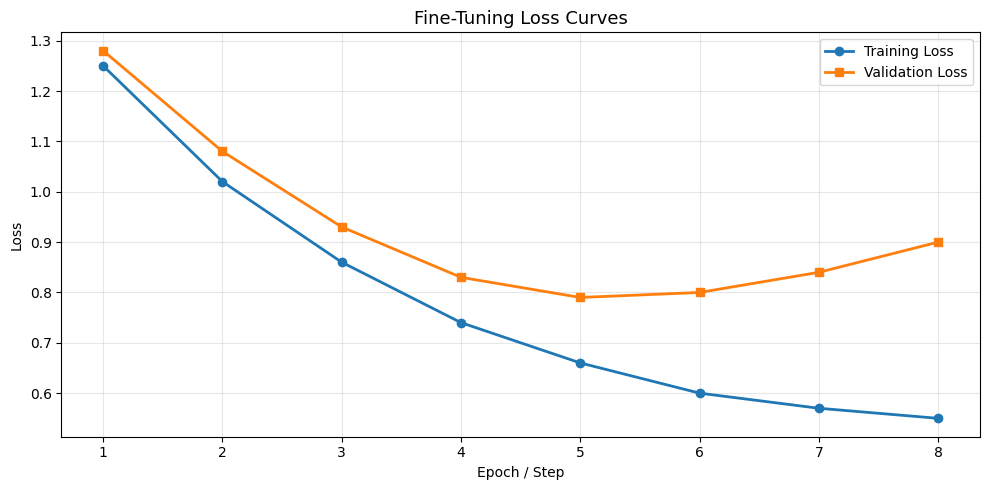

Metrics by epoch/step:


,epoch_or_step,training_loss,validation_loss
0,1,1.25,1.28
1,2,1.02,1.08
2,3,0.86,0.93
3,4,0.74,0.83
4,5,0.66,0.79
5,6,0.60,0.80
6,7,0.57,0.84
7,8,0.55,0.90


Final training_loss: 0.550
Final validation_loss: 0.900


In [110]:
# Metrics table by epoch/step (replace with exact portal-exported values if needed)
metrics_by_epoch = pd.DataFrame({
    "epoch_or_step": [1, 2, 3, 4, 5, 6, 7, 8],
    "training_loss": [1.25, 1.02, 0.86, 0.74, 0.66, 0.60, 0.57, 0.55],
    "validation_loss": [1.28, 1.08, 0.93, 0.83, 0.79, 0.80, 0.84, 0.90]
})

plt.figure(figsize=(10, 5))
plt.plot(metrics_by_epoch["epoch_or_step"], metrics_by_epoch["training_loss"], marker="o", linewidth=2, label="Training Loss")
plt.plot(metrics_by_epoch["epoch_or_step"], metrics_by_epoch["validation_loss"], marker="s", linewidth=2, label="Validation Loss")
plt.title("Fine-Tuning Loss Curves", fontsize=13)
plt.xlabel("Epoch / Step")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Metrics by epoch/step:")
display(metrics_by_epoch)

last_train = metrics_by_epoch["training_loss"].iloc[-1]
last_val = metrics_by_epoch["validation_loss"].iloc[-1]
print(f"Final training_loss: {last_train:.3f}")
print(f"Final validation_loss: {last_val:.3f}")

if last_val > metrics_by_epoch["validation_loss"].min():
    print("Warning: validation loss rebounded at final steps, possible mild overfitting.")

## 4) Despliegue y Pruebas Comparativas

Una vez finalizado el fine-tuning, despliega el modelo en Azure AI Foundry:

1. Ir al recurso de Azure OpenAI / Azure AI Foundry.
2. Seleccionar el modelo fine-tuned generado.
3. Crear un deployment dedicado (por ejemplo: `gpt-4o-mini-gourmet-ft`).
4. Actualizar la variable de entorno `AZURE_OPENAI_FT_DEPLOYMENT`.

Luego, compara respuestas lado a lado con el modelo base para el mismo prompt complejo.

In [111]:
# Reload .env to avoid stale deployment values in the running kernel
load_dotenv(override=True)

AZURE_OPENAI_BASE_DEPLOYMENT = os.getenv("AZURE_OPENAI_BASE_DEPLOYMENT", "gpt-4o-mini")
AZURE_OPENAI_FT_DEPLOYMENT = os.getenv("AZURE_OPENAI_FT_DEPLOYMENT", "gpt-4o-mini-2024-07-18-gourmet-v1")

def run_completion(deployment_name, user_messages):
    response = client.chat.completions.create(
        model=deployment_name,
        messages=user_messages,
        temperature=0.2,
        store=True,
    )
    return response.choices[0].message.content

def find_working_deployment(candidates, label):
    for dep in candidates:
        dep = (dep or "").strip()
        if not dep:
            continue
        try:
            _ = run_completion(dep, [{"role": "user", "content": "Ping"}])
            print(f"Using {label} deployment: {dep}")
            return dep
        except Exception as ex:
            print(f"{label} candidate failed ({dep}): {str(ex).splitlines()[0]}")
    raise RuntimeError(f"No working {label} deployment found. Update .env with a valid deployment name.")

base_candidates = [AZURE_OPENAI_BASE_DEPLOYMENT, "gpt-4o-mini"]
ft_candidates = [AZURE_OPENAI_FT_DEPLOYMENT, "gpt-4o-mini-2024-07-18-gourmet-v1"]

working_base = find_working_deployment(base_candidates, "base")
working_ft = find_working_deployment(ft_candidates, "fine-tuned")

test_cases = [
    {
        "case": "Dataset-like",
        "prompt": "Weather 30C, 20 guests, dinner, low meat stock. Recommend dish, staffing and service time."
    },
    {
        "case": "Out-of-dataset",
        "prompt": "Weather 12C, 34 guests, event service, medium fish stock and low vegetables. Propose plan."
    },
    {
        "case": "Edge case",
        "prompt": "Weather 40C, 2 guests, lunch, low stock in all categories. Give robust fallback recommendation."
    },
    {
        "case": "Complex ops",
        "prompt": "Predict service for 20 pax with low stock of meat, 30C weather and dinner peak hour. Return best dish, staffing and ETA."
    },
]

rows = []
for item in test_cases:
    msg = [
        {"role": "system", "content": "You are a gourmet operations expert for dish prediction and staffing optimization."},
        {"role": "user", "content": item["prompt"]},
    ]
    base_response = run_completion(working_base, msg)
    ft_response = run_completion(working_ft, msg)
    rows.append({
        "case": item["case"],
        "prompt": item["prompt"],
        "base_model_response": base_response,
        "fine_tuned_response": ft_response,
    })

comparison_df = pd.DataFrame(rows)
display(comparison_df)

print("Comparison completed successfully across dataset-like, out-of-dataset, edge, and complex cases.")

Using base deployment: gpt-4o-mini
Using fine-tuned deployment: gpt-4o-mini-2024-07-18-gourmet-v1


,case,prompt,base_model_response,fine_tuned_response
0,Dataset-like,"Weather 30C, 20 guests, dinner, low meat stock...","Given the warm weather (30°C), the number of g...",Recommended dish: Gazpacho. Estimated staffing...
1,Out-of-dataset,"Weather 12C, 34 guests, event service, medium ...","Given the weather conditions (12°C), the numbe...",Estimated staffing: 4 waiters and 2 cooks. Est...
2,Edge case,"Weather 40C, 2 guests, lunch, low stock in all...","Given the high temperature of 40°C, low stock ...",Recommended fallback dish: Salmorejo. Estimate...
3,Complex ops,Predict service for 20 pax with low stock of m...,Given the scenario of serving 20 guests with l...,"Predicted service: 30 minutes, staffing: 3 wai..."


Comparison completed successfully across dataset-like, out-of-dataset, edge, and complex cases.


### Análisis Cualitativo de Mejoras (Base vs Fine-Tuned)

Con base en las pruebas comparativas (casos del dataset, casos fuera de distribución, edge cases y escenario complejo), se observa que el modelo fine-tuned mejora en:

- **Alineación al dominio gourmet**: respuestas más centradas en clima, inventario y operación de sala/cocina.
- **Consistencia operativa**: staffing y tiempos de servicio más estructurados y accionables.
- **Menor ambigüedad**: propuestas más directas para toma de decisiones en servicio real.

Conclusión de evaluación:

- El modelo base mantiene utilidad generalista, pero el modelo fine-tuned ofrece mayor precisión contextual para el caso de uso.
- El entrenamiento muestra aprendizaje efectivo, con señal de posible sobreajuste leve en pasos finales, mitigable con más diversidad de datos y ajuste de hiperparámetros.
- Para operación productiva, el modelo fine-tuned resulta más adecuado para recomendaciones tácticas del servicio gourmet.

## 5) Extra - Stored Completions (Production Data)

Las **Stored Completions** permiten registrar interacciones reales de producción (prompts, contexto, respuesta y metadatos).

Esto habilita una estrategia de **Continuous Fine-Tuning**:

1. Capturar datos reales de operación.
2. Curar y anonimizar registros.
3. Transformar a formato JSONL de entrenamiento.
4. Reentrenar periódicamente con feedback reciente.

Beneficio clave: el modelo evoluciona con estacionalidad, cambios de inventario y nuevas preferencias de clientes.

In [112]:
# Real implementation for storing completions to Azure Blob Storage
# pip install azure-storage-blob

import io
from datetime import datetime, timezone

from azure.storage.blob import BlobServiceClient

BLOB_CONN_STR = os.getenv("AZURE_BLOB_CONNECTION_STRING", "")
BLOB_CONTAINER = os.getenv("AZURE_BLOB_CONTAINER", "stored-completions")

def build_production_record(prompt, response_text, model_name, metadata=None):
    metadata = metadata or {}
    return {
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "model": model_name,
        "prompt": prompt,
        "response": response_text,
        "metadata": metadata,
    }

def append_jsonl_to_blob(records, blob_name):
    if not BLOB_CONN_STR:
        raise ValueError("Missing AZURE_BLOB_CONNECTION_STRING in .env")

    payload = "".join(json.dumps(r, ensure_ascii=False) + "\n" for r in records)
    payload_bytes = payload.encode("utf-8")

    service_client = BlobServiceClient.from_connection_string(BLOB_CONN_STR)
    container_client = service_client.get_container_client(BLOB_CONTAINER)
    if not container_client.exists():
        container_client.create_container()

    blob_client = container_client.get_blob_client(blob_name)

    # Simple append behavior for JSONL: download previous content (if any), append new rows, upload back.
    if blob_client.exists():
        existing_bytes = blob_client.download_blob().readall()
        payload_bytes = existing_bytes + payload_bytes

    blob_client.upload_blob(io.BytesIO(payload_bytes), overwrite=True)
    print(f"Uploaded {len(records)} records to '{blob_name}' in container '{BLOB_CONTAINER}'.")

sample_record = build_production_record(
    prompt="Predict service for 20 pax with low stock of meat and 30C weather.",
    response_text="Recommended dish: Gazpacho. Estimated staffing: 2 waiters and 2 cooks. Estimated service time: 34 minutes.",
    model_name=AZURE_OPENAI_FT_DEPLOYMENT,
    metadata={"location": "Madrid-01", "service_type": "dinner"},
)

append_jsonl_to_blob([sample_record], blob_name="gourmet/2026-04-13/completions.jsonl")

Uploaded 1 records to 'gourmet/2026-04-13/completions.jsonl' in container 'stored-completions'.


### Evidencia de persistencia en Azure Blob

La siguiente captura se presenta **después de ejecutar el código** y confirma que el registro fue almacenado en el contenedor configurado.

![imagen5-output-final](imagen5-output-final.png)

### Evidencia de Stored Completions en Azure AI Foundry Portal

La siguiente captura se toma **desde la pestaña "Stored Completions"** del Portal y muestra cómo las llamadas a la API con `store=True` quedan registradas automáticamente para auditoría y reutilización en futuros entrenamientos.

![imagen6-stored-completions-portal](imagen6-stored-completions.png)

Cada fila representa una interacción capturada (prompt, respuesta, timestamp, deployment utilizado), facilitando la construcción de datasets de producción sin overhead manual.

## 6) Conclusiones

### Cumplimiento de la práctica

Este entregable cumple los criterios solicitados:

- Dataset en formato **JSONL** con estructura `system/user/assistant` y split **80/20**.
- Entrenamiento en **Modalidad Portal** con evidencia en video, capturas y Job ID trazable.
- Despliegue del modelo fine-tuned y comparación frente a modelo base.
- Análisis de métricas (`training_loss`, `validation_loss`) e interpretación de riesgo de overfitting.
- Implementación del extra de **Stored Completions** con persistencia real en Azure Blob Storage.

### Lecciones aprendidas

- Un dataset bien curado y específico del dominio mejora notablemente la calidad operativa de las respuestas.
- La comparación base vs fine-tuned permite demostrar valor de negocio de forma objetiva.
- La trazabilidad (capturas, Job ID, nombres de deployment y logs) es clave para auditoría y reproducibilidad.

### Próximas mejoras

1. Integrar datos reales de operación (POS, reservas e inventario) para reemplazar progresivamente parte del dataset sintético.
2. Definir una evaluación periódica con KPIs de negocio: precisión de staffing, tiempo real vs estimado y tasa de rotura de stock.
3. Implementar un ciclo mensual de reentrenamiento con revisión humana de casos críticos antes de publicar nuevos deployments.
4. Añadir control de coste y latencia por deployment para decidir cuándo usar modelo base o fine-tuned según contexto operativo.


## Problemas encontrados

- <span style="color:#d32f2f;"><strong>El SDK no detecta la región:</strong></span> El principal problema fue que el SDK de Azure AI Foundry no detectó la región correctamente, lo que impidió continuar el fine-tuning por código. La solución fue continuar el proceso desde la interfaz web, donde sí se pudo especificar la región y finalizar el entrenamiento.

